In [1]:
import pandas as pd 
import seaborn as sb
import matplotlib.pyplot as plt
import warnings
warnings.simplefilter(action="ignore", category=FutureWarning)
import pingouin as pg
plt.style.use('/Users/amonast/Documents/GitHub/CA1_Engram_Dynamics/figures/paper_style.mplstyle')
gray='#424949'
colors = ['#00ABC8','#F37243'] #Non-engram, Engram


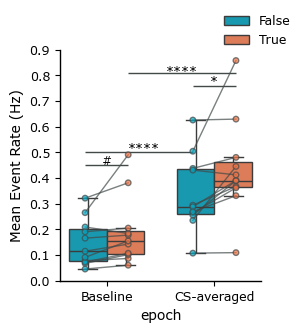

In [9]:
baseline_v_trialavg = pd.read_csv(f"/Users/amonast/Desktop/Tone2P/Analysis/rates/recall1_baselinevtrialavg.csv")

plt.figure(figsize=(2.6,3))
sb.boxplot(data=baseline_v_trialavg,x='epoch',y='mean_rate',hue='is_engram',palette=colors,width=.7,linewidth=1,showfliers=False)
sb.stripplot(data=baseline_v_trialavg, x='epoch', y='mean_rate', hue='is_engram', palette=colors, 
             edgecolor=gray, linewidth=1, dodge=10,jitter=0, alpha=.7, size=4,legend=False)

for i, animal in enumerate(baseline_v_trialavg['animal'].unique()):
    animal_data = baseline_v_trialavg[baseline_v_trialavg['animal'] == animal]
    for epoch in animal_data['epoch'].unique():
        if epoch=='baseline':
            x1,x2=-.2,.2
        else:
            x1,x2=.8,1.2
        engram_data = animal_data[(animal_data['epoch'] == epoch) & (animal_data['is_engram'] == 1)]
        nonengram_data = animal_data[(animal_data['epoch'] == epoch) & (animal_data['is_engram'] == 0)]
        
        if not engram_data.empty and not nonengram_data.empty:
            plt.plot([x1, x2], [nonengram_data['mean_rate'].values[0],engram_data['mean_rate'].values[0],], 
                     color=gray, linewidth=1, alpha=0.7)

plt.ylim(0,.9)
plt.hlines(.5, -.2, .8, color=gray, linewidth=1)
plt.text(ha='center', x=.35, y=.5, s='****', size=9)
plt.hlines(.45, -.2, .2, color=gray, linewidth=1)
plt.text(ha='center', x=0, y=.45, s='#', size=9)
plt.hlines(.81, .2, 1.2, color=gray, linewidth=1)
plt.text(ha='center', x=.7, y=.8, s='****', size=9)
plt.hlines(.76, .8, 1.2, color=gray, linewidth=1)
plt.text(ha='center', x=1, y=.76, s='*', size=9)
plt.legend(loc='upper right', bbox_to_anchor=(1.2, 1.2), frameon=False)
plt.xticks(ticks=[0, 1], labels=['Baseline', 'CS-averaged'],size=9)
plt.ylabel('Mean Event Rate (Hz)')

sb.despine()
plt.savefig('Figure5D_boxplot_meanrates_baselinevtrialavg.svg',transparent=True)


In [3]:
pg.rm_anova(data=baseline_v_trialavg,within=['epoch','is_engram'],dv='mean_rate',subject='animal')

,Source,SS,ddof1,ddof2,MS,F,p-unc,p-GG-corr,ng2,eps
0,epoch,0.517447,1,10,0.517447,103.954379,0.000001,0.000001,0.387077,1.0
1,is_engram,0.053469,1,10,0.053469,7.947527,0.018188,0.018188,0.061260,1.0
2,epoch * is_engram,0.007979,1,10,0.007979,6.658132,0.027401,0.027401,0.009644,1.0


In [4]:
pg.pairwise_tests(data=baseline_v_trialavg,within=['epoch','is_engram'],dv='mean_rate',subject='animal',padjust='fdr_bh')


,Contrast,epoch,A,B,Paired,Parametric,T,dof,alternative,p-unc,p-corr,p-adjust,BF10,hedges
0,epoch,-,baseline,trial_avg,True,True,-10.195802,10.0,two-sided,0.000001,NaN,NaN,1.25e+04,-1.533940
1,is_engram,-,False,True,True,True,-2.819136,10.0,two-sided,0.018188,NaN,NaN,3.75,-0.487362
2,epoch * is_engram,baseline,False,True,True,True,-2.167761,10.0,two-sided,0.055379,0.055379,fdr_bh,1.58,-0.364682
3,epoch * is_engram,trial_avg,False,True,True,True,-2.980585,10.0,two-sided,0.013794,0.027588,fdr_bh,4.674,-0.553425


In [5]:
pg.pairwise_tests(data=baseline_v_trialavg,within=['is_engram','epoch'],dv='mean_rate',subject='animal',padjust='fdr_bh')


,Contrast,is_engram,A,B,Paired,Parametric,T,dof,alternative,p-unc,p-corr,p-adjust,BF10,hedges
0,is_engram,-,False,True,True,True,-2.819136,10.0,two-sided,0.018188,NaN,NaN,3.75,-0.487362
1,epoch,-,baseline,trial_avg,True,True,-10.195802,10.0,two-sided,0.000001,NaN,NaN,1.25e+04,-1.533940
2,is_engram * epoch,False,baseline,trial_avg,True,True,-9.140420,10.0,two-sided,0.000004,0.000004,fdr_bh,5199.848,-1.501798
3,is_engram * epoch,True,baseline,trial_avg,True,True,-9.275287,10.0,two-sided,0.000003,0.000004,fdr_bh,5841.197,-1.450199
